# 2. Modeling

**Construir, entrenar y validar un modelo de Regresión Lineal** que prediga los costos médicos anuales (`charges`) utilizando un Pipeline profesional de Scikit-Learn, asegurando reproducibilidad, evitando data leakage y siguiendo estándares de la industria.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml
import logging
from typing import Tuple, List

In [5]:
df = pd.read_csv("../data/processed/01_insurance.csv")
df.sample(10) 

,age,sex,bmi,children,smoker,region,charges,log_charges
73,58,male,32.010,1,no,southeast,11946.62590,9.388288
1285,28,female,17.290,0,no,northeast,3732.62510,8.225135
576,22,male,26.840,0,no,southeast,1664.99960,7.418181
202,60,female,24.035,0,no,northwest,13012.20865,9.473720
96,54,female,30.800,3,no,southwest,12105.32000,9.401483
64,20,female,22.420,0,yes,northwest,14711.74380,9.596469
32,19,female,28.600,5,no,southwest,4687.79700,8.452931
913,33,male,24.605,2,no,northwest,5257.50795,8.567603
1181,25,female,30.300,0,no,southwest,2632.99200,7.876256
377,24,male,40.150,0,yes,southeast,38126.24650,10.548684


## 2.1 DEFINICIÓN DE VARIABLES Y SEPARACIÓN

In [6]:
X = df.drop('charges', axis=1)
y = df['charges']

In [7]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
target = 'charges'

## 2.2 TRANSFORMACIÓN DE LA VARIABLE OBJETIVO

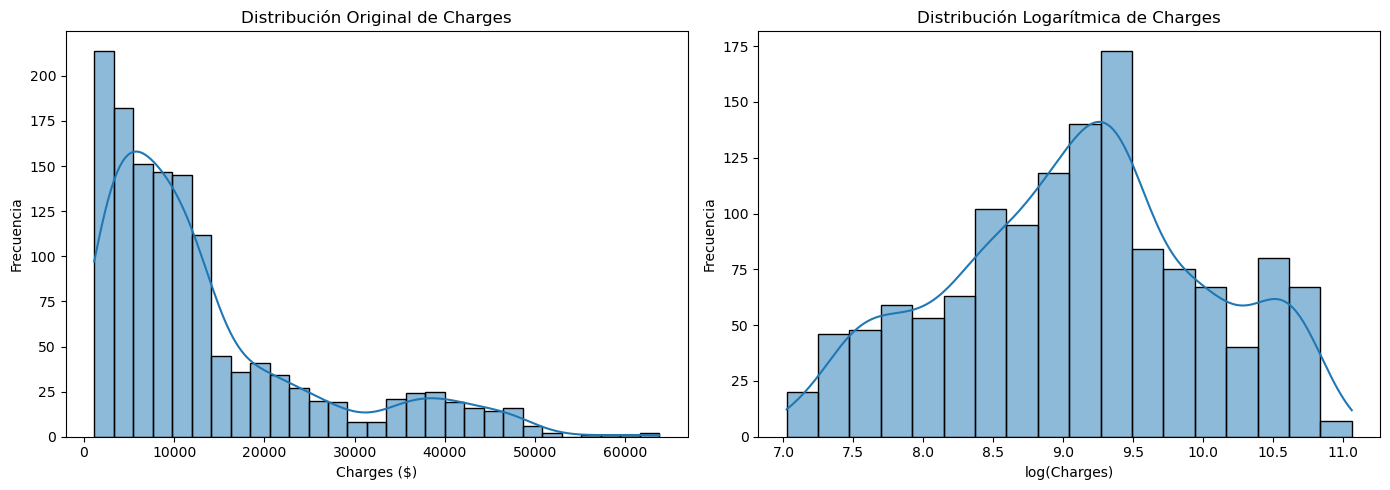

Asimetría original: 1.51
Asimetría logarítmica: -0.09


In [9]:
# 3.1 Verificar distribución de charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
sns.histplot(y, kde=True, ax=axes[0])
axes[0].set_title('Distribución Original de Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frecuencia')

# Distribución logarítmica
y_log = np.log(y)
sns.histplot(y_log, kde=True, ax=axes[1])
axes[1].set_title('Distribución Logarítmica de Charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 3.2 Decidir transformación
# Calcular asimetría
from scipy.stats import skew
skew_original = skew(y)
skew_log = skew(y_log)

print(f"Asimetría original: {skew_original:.2f}")
print(f"Asimetría logarítmica: {skew_log:.2f}")

